In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity


In [ ]:
from google.colab import files
import os
import pandas as pd
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
file_path = os.path.join(os.getcwd(), file_name)
data = pd.read_excel(file_path)
print(data.head())
data

Saving OnlineRetail (1).xlsx to OnlineRetail (1) (9).xlsx
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

          InvoiceDate  UnitPrice  CustomerID         Country  
0 2010-12-01 08:26:00       2.55     17850.0  United Kingdom  
1 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
2 2010-12-01 08:26:00       2.75     17850.0  United Kingdom  
3 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  
4 2010-12-01 08:26:00       3.39     17850.0  United Kingdom  


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [ ]:
data = data[data['CustomerID'].notnull()]
data = data[data['Quantity'] > 0]

data.drop_duplicates(inplace=True)

data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])

data.shape


(392732, 8)

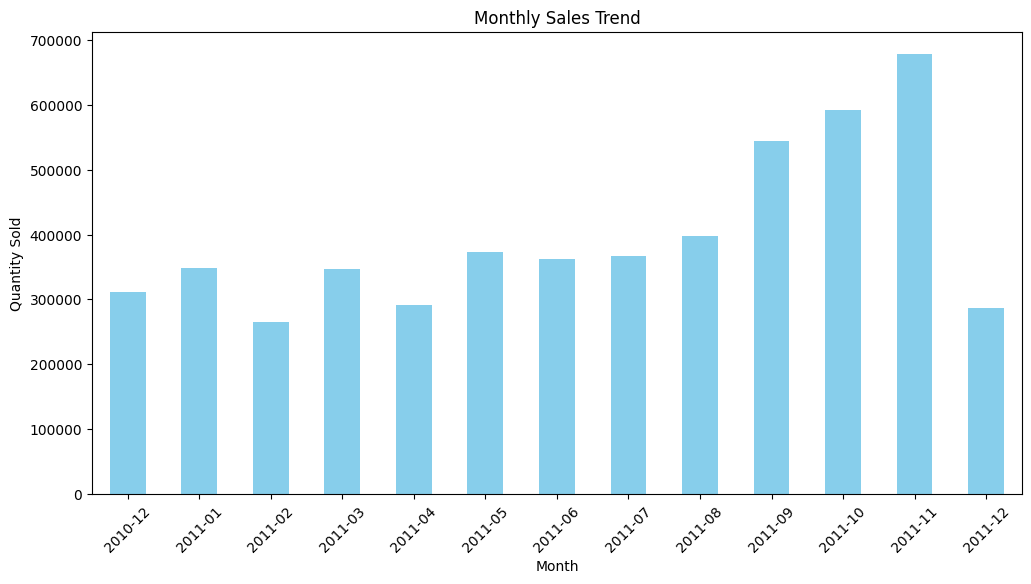

In [ ]:
data['Month'] = data['InvoiceDate'].dt.to_period('M')
monthly_sales = data.groupby('Month')['Quantity'].sum()
plt.figure(figsize=(12,6))
monthly_sales.plot(kind='bar', color='skyblue')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()


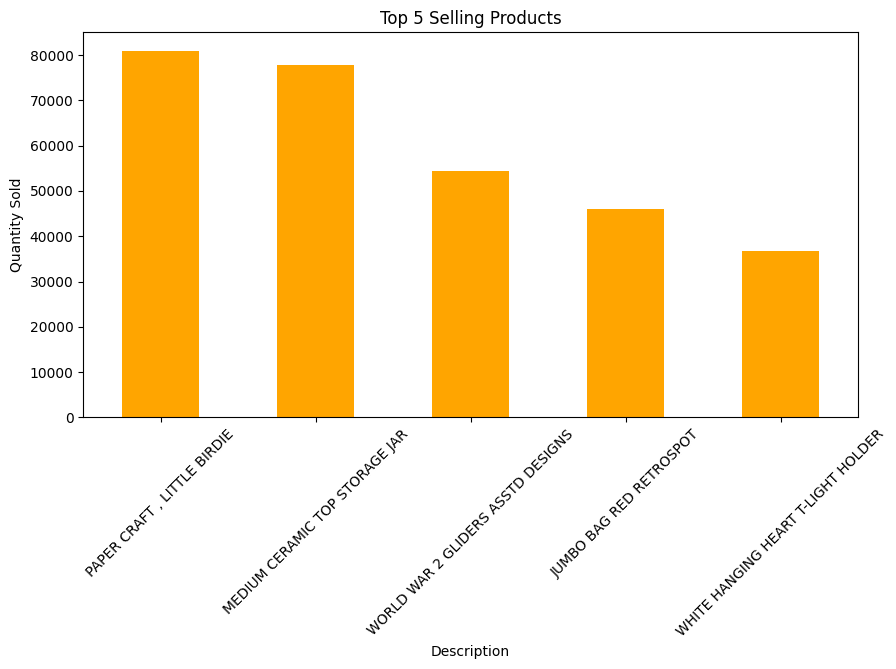

In [ ]:
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
top_products.plot(kind='bar', color='orange', figsize=(10,5))
plt.title('Top 5 Selling Products')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()


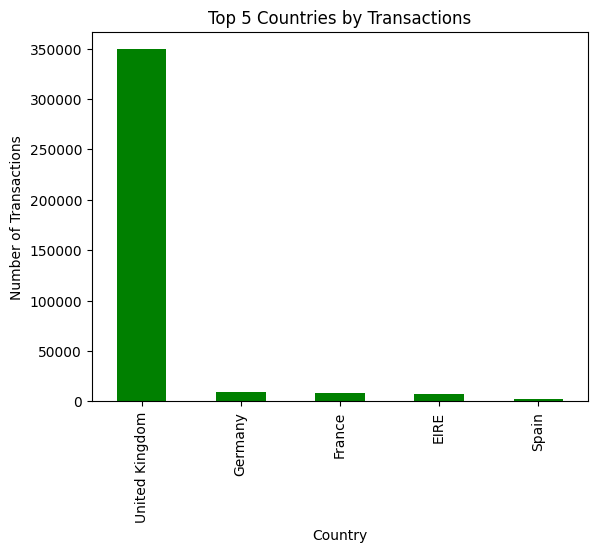

In [ ]:

top_countries = data['Country'].value_counts().head(5)
top_countries.plot(kind='bar', color='green')
plt.title('Top 5 Countries by Transactions')
plt.ylabel('Number of Transactions')
plt.show()


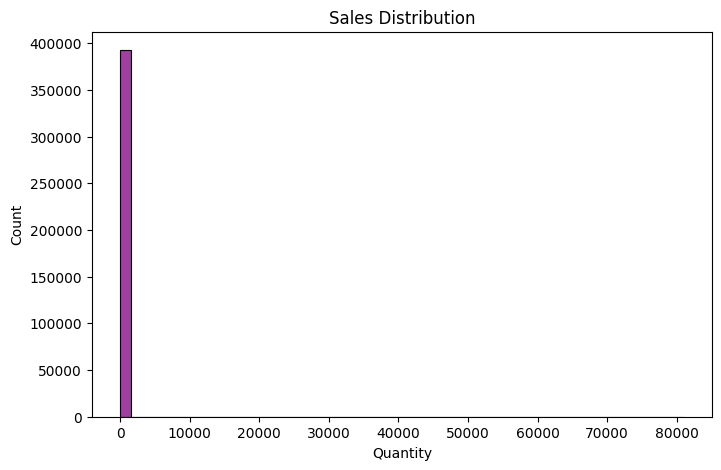

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data['Quantity'], bins=50, color='purple')
plt.title('Sales Distribution')
plt.show()


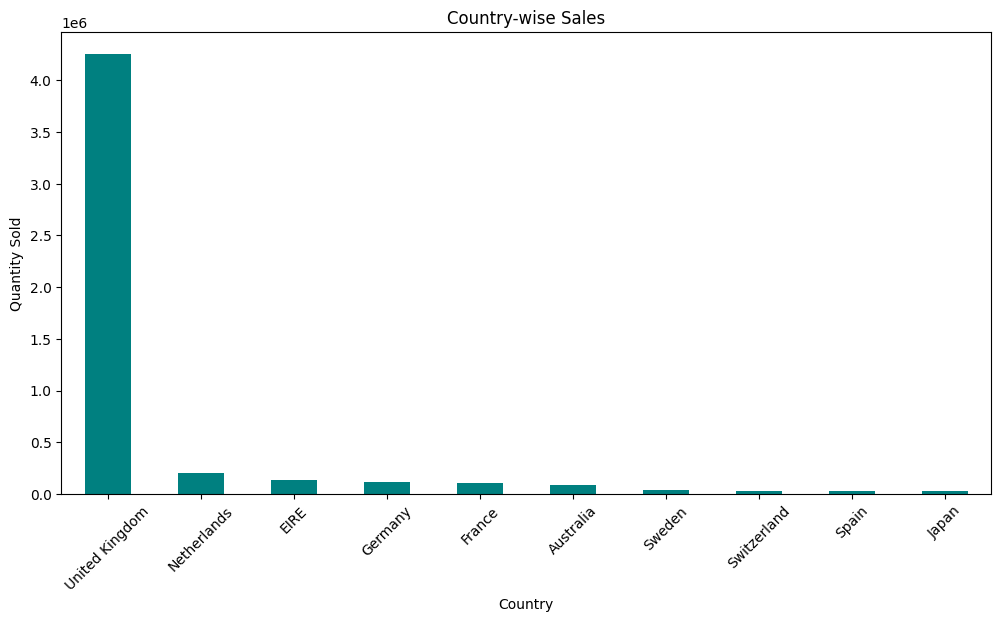

In [ ]:
country_sales = data.groupby('Country')['Quantity'].sum().sort_values(ascending=False).head(10)
country_sales.plot(kind='bar', color='teal', figsize=(12,6))
plt.title('Country-wise Sales')
plt.ylabel('Quantity Sold')
plt.xticks(rotation=45)
plt.show()


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Correlation Matrix:

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


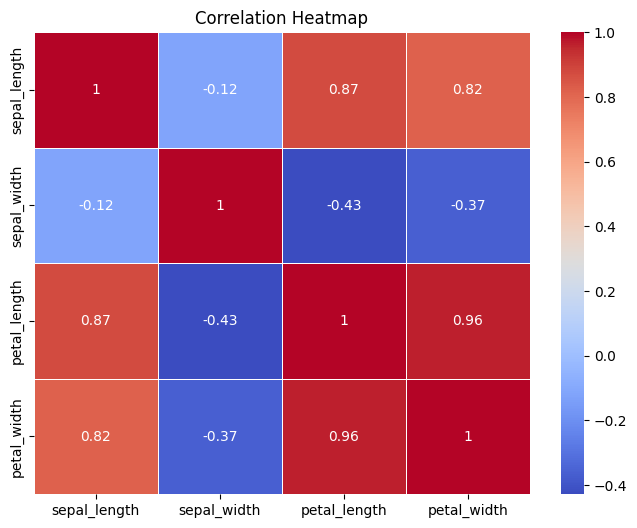

In [ ]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = sns.load_dataset('iris')
print(df.head())
correlation_matrix = df.corr(numeric_only=True)
print("\nCorrelation Matrix:\n")
print(correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()



In [ ]:
pivot = data.pivot_table(index='CustomerID', columns='StockCode', values='Quantity', fill_value=0)
similarity = cosine_similarity(pivot)

similarity_df = pd.DataFrame(similarity, index=pivot.index, columns=pivot.index)
similarity_df.head()


CustomerID,12346.0,12347.0,12348.0,12349.0,12350.0,12352.0,12353.0,12354.0,12355.0,12356.0,...,18273.0,18274.0,18276.0,18277.0,18278.0,18280.0,18281.0,18282.0,18283.0,18287.0
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
12347.0,0.0,1.000000,0.168295,0.014255,0.020347,0.012045,0.0,0.007334,0.710717,0.074592,...,0.0,0.000427,0.419403,0.0,0.004266,0.011435,0.0,0.007698,0.037350,0.109131
12348.0,0.0,0.168295,1.000000,0.000054,0.000100,0.000111,0.0,0.013503,0.248133,0.159318,...,0.0,0.041280,0.139386,0.0,0.000000,0.000000,0.0,0.000000,0.211032,0.071888
12349.0,0.0,0.014255,0.000054,1.000000,0.030121,0.148970,0.0,0.004931,0.000180,0.175003,...,0.0,0.148066,0.000000,0.0,0.015680,0.000000,0.0,0.013398,0.102726,0.032087
12350.0,0.0,0.020347,0.000100,0.030121,1.000000,0.000431,0.0,0.000000,0.000000,0.001373,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.028372,0.000000


In [ ]:


import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

data = {
    'CustomerID': [1, 2, 3, 4, 5],
    'Age': [25, 30, 45, 35, 50],
    'Income': [50000, 60000, 80000, 75000, 90000]
}

df = pd.DataFrame(data)
df.set_index('CustomerID', inplace=True)  # Set CustomerID as Index

similarity = cosine_similarity(df)
similarity_df = pd.DataFrame(similarity, index=df.index, columns=df.index)

print("Customer Similarity Matrix:\n")
print(similarity_df)

def recommend_similar(customer_id):
    if customer_id in similarity_df.index:
        similar_customers = similarity_df.loc[customer_id].sort_values(ascending=False)[1:6]
        print(f"\nTop 5 Customers similar to Customer ID {customer_id}:\n")
        print(similar_customers)
    else:
        print("Customer ID not found in dataset.")
recommend_similar(3)



Customer Similarity Matrix:

CustomerID    1    2    3    4    5
CustomerID                         
1           1.0  1.0  1.0  1.0  1.0
2           1.0  1.0  1.0  1.0  1.0
3           1.0  1.0  1.0  1.0  1.0
4           1.0  1.0  1.0  1.0  1.0
5           1.0  1.0  1.0  1.0  1.0

Top 5 Customers similar to Customer ID 3:

CustomerID
5    1.0
1    1.0
2    1.0
4    1.0
Name: 3, dtype: float64
